In [1]:
import cv2
import joblib
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

In [2]:
#Load Data
faces = fetch_olivetti_faces()
X = faces.images
y = faces.target
print("Images :", X.shape)
print("Labels :", y.shape)

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data
Images : (400, 64, 64)
Labels : (400,)


In [3]:
def preprocess_images(images):
    processed = []
    for img in images:
        img = cv2.resize(img, (64,64))
        img = img.astype(np.float32)
        img = cv2.equalizeHist((img*255).astype(np.uint8))
        img = img / 255.0
        processed.append(img)
    return np.array(processed)

In [4]:
def extract_features(images):
    images = images.reshape(len(images), -1)
    pca = PCA(n_components=100, whiten=True)
    features = pca.fit_transform(images)
    return features, pca

In [14]:
#Preprocess
X = preprocess_images(X)

In [6]:
#Feature Extraction
X, pca = extract_features(X)
print(X.shape)

(400, 100)


In [7]:
#Train Test Split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [13]:
#Model Accuracy
model = SVC(kernel='rbf',probability=True)
model.fit(X_train,y_train)

prediction = model.predict(X_test)
accuracy = accuracy_score(y_test,prediction)
print("Accuracy :",accuracy*100,"%")
print(classification_report(y_test,prediction))

Accuracy : 95.0 %
              precision    recall  f1-score   support

           0       0.67      1.00      0.80         2
           1       1.00      1.00      1.00         2
           2       1.00      1.00      1.00         2
           3       1.00      1.00      1.00         2
           4       1.00      0.50      0.67         2
           5       1.00      1.00      1.00         2
           6       1.00      0.50      0.67         2
           7       0.67      1.00      0.80         2
           8       1.00      1.00      1.00         2
           9       1.00      0.50      0.67         2
          10       1.00      1.00      1.00         2
          11       1.00      1.00      1.00         2
          12       1.00      1.00      1.00         2
          13       1.00      1.00      1.00         2
          14       1.00      1.00      1.00         2
          15       0.67      1.00      0.80         2
          16       1.00      1.00      1.00         2
         

In [10]:
#Prediction
index = 10
sample = X_test[index].reshape(1,-1)
pred = model.predict(sample)
confidence = np.max(model.predict_proba(sample))*100
print("Predicted Person ID :",pred[0])
print("Confidence :",round(confidence,2),"%")

Predicted Person ID : 25
Confidence : 56.39 %


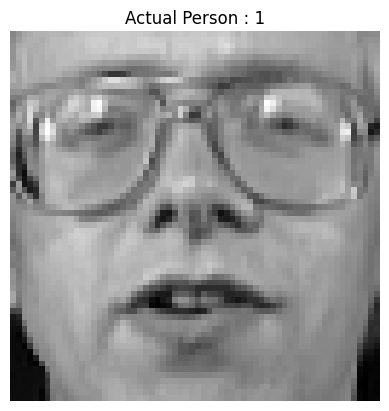

In [11]:
#Show Image
plt.imshow(faces.images[index], cmap='gray')
plt.title("Actual Person : {}".format(faces.target[index]))
plt.axis("off")
plt.show()

In [12]:
#Save Model
joblib.dump(model,"face_model.pkl")
joblib.dump(pca,"pca.pkl")
joblib.dump(scaler,"scaler.pkl")

['scaler.pkl']